In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
df = pd.read_csv('/content/drive/MyDrive/all_stocks_5yr.csv')
display(df.head())

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [ ]:
missing_values = df.isnull().sum()
print("Missing Value Analysis:")
print(missing_values[missing_values > 0])
print("\nRatio of Missing Values to Total Values(%):")
missing_ratio = (df.isnull().sum() / len(df)) * 100
print(missing_ratio[missing_ratio > 0])

Missing Value Analysis:
open    11
high     8
low      8
dtype: int64

Ratio of Missing Values to Total Values(%):
open    0.001777
high    0.001292
low     0.001292
dtype: float64


In [ ]:
print("1. Dataset Dimensions (Shape):")
print(f"Total Rows (Trading Days): {df.shape[0]}")
print(f"Total Columns (Variables): {df.shape[1]}\n")

print("2.Variable Types:")
print(df.dtypes, "\n")

print("Descriptive Statistics):")
display(df.describe().T)

1. Dataset Dimensions (Shape):
Total Rows (Trading Days): 619040
Total Columns (Variables): 7

2.Variable Types:
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
Name       object
dtype: object 

Descriptive Statistics):


,count,mean,std,min,25%,50%,75%,max
open,619029.0,8.302333e+01,9.737877e+01,1.62,40.220,62.59,94.37,2.044000e+03
high,619032.0,8.377831e+01,9.820752e+01,1.69,40.620,63.15,95.18,2.067990e+03
low,619032.0,8.225610e+01,9.650742e+01,1.50,39.830,62.02,93.54,2.035110e+03
close,619040.0,8.304376e+01,9.738975e+01,1.59,40.245,62.62,94.41,2.049000e+03
volume,619040.0,4.321823e+06,8.693610e+06,0.00,1070320.500,2082093.50,4284509.25,6.182376e+08


In [ ]:

print("Correlation with Target Variable :")

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()

target_correlation = correlation_matrix[['close']].sort_values(by='close', ascending=False)
display(target_correlation)

Correlation with Target Variable :


,close
close,1.000000
low,0.999939
high,0.999936
open,0.999872
volume,-0.142802


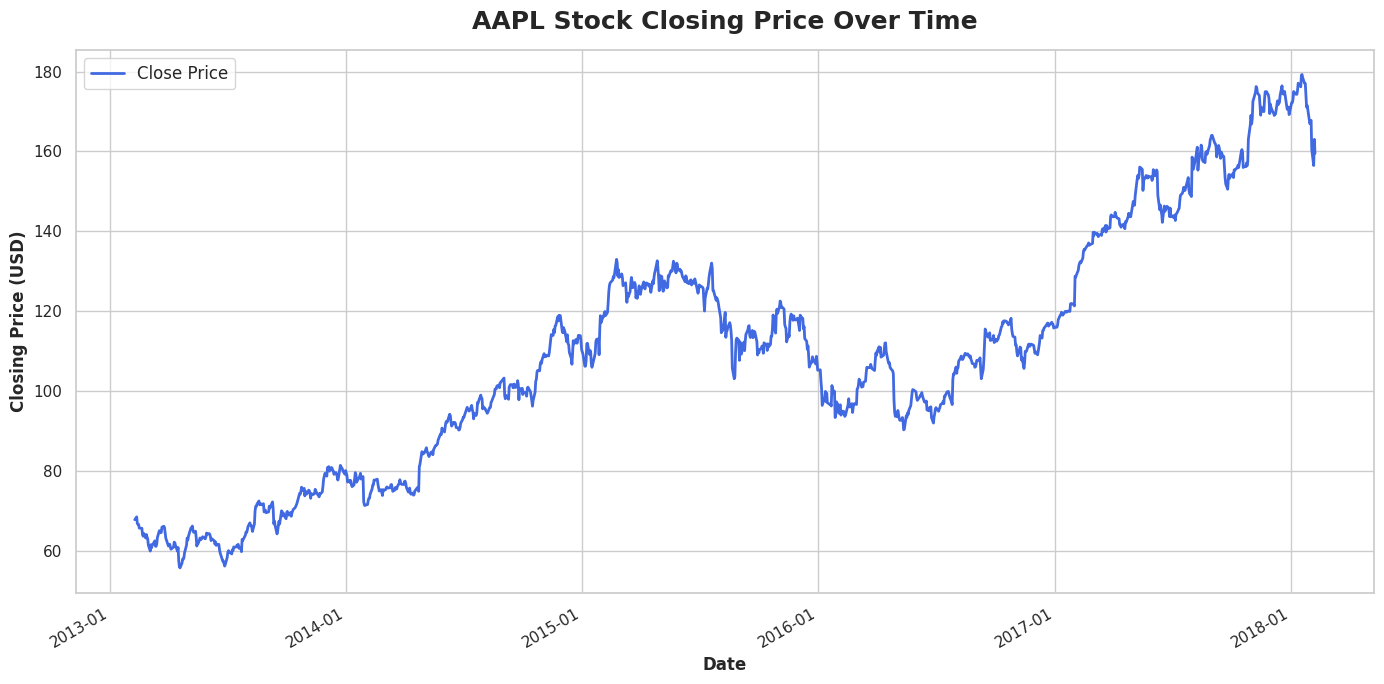

In [ ]:

import matplotlib.dates as mdates
sns.set_theme(style="whitegrid")

target_stock = 'AAPL'
df_chart = df[df['Name'] == target_stock].copy()

df_chart['date'] = pd.to_datetime(df_chart['date'])
df_chart = df_chart.sort_values('date')

plt.figure(figsize=(14, 7))

plt.plot(df_chart['date'], df_chart['close'], color='royalblue', linewidth=2, label='Close Price')

plt.title(f'{target_stock} Stock Closing Price Over Time', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Closing Price (USD)', fontsize=12, fontweight='bold')

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()

plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()

plt.show()

In [ ]:

target_stock = 'AAPL'
df_candle = df[df['Name'] == target_stock].copy()

df_candle['date'] = pd.to_datetime(df_candle['date'])
df_candle = df_candle.sort_values('date')

df_candle = df_candle.tail(150)

fig = go.Figure(data=[go.Candlestick(
    x=df_candle['date'],
    open=df_candle['open'],
    high=df_candle['high'],
    low=df_candle['low'],
    close=df_candle['close'],
    name=target_stock,
    increasing_line_color='mediumseagreen',
    decreasing_line_color='tomato'
    )])

fig.update_layout(
    title=f'{target_stock} Interactive Candlestick Chart (Last 150 Days)',
    title_font=dict(size=20, color='white'),
    yaxis_title='Stock Price (USD)',
    xaxis_title='Date',
    template='plotly_dark',
    xaxis_rangeslider_visible=True,
    height=700
)

fig.show()

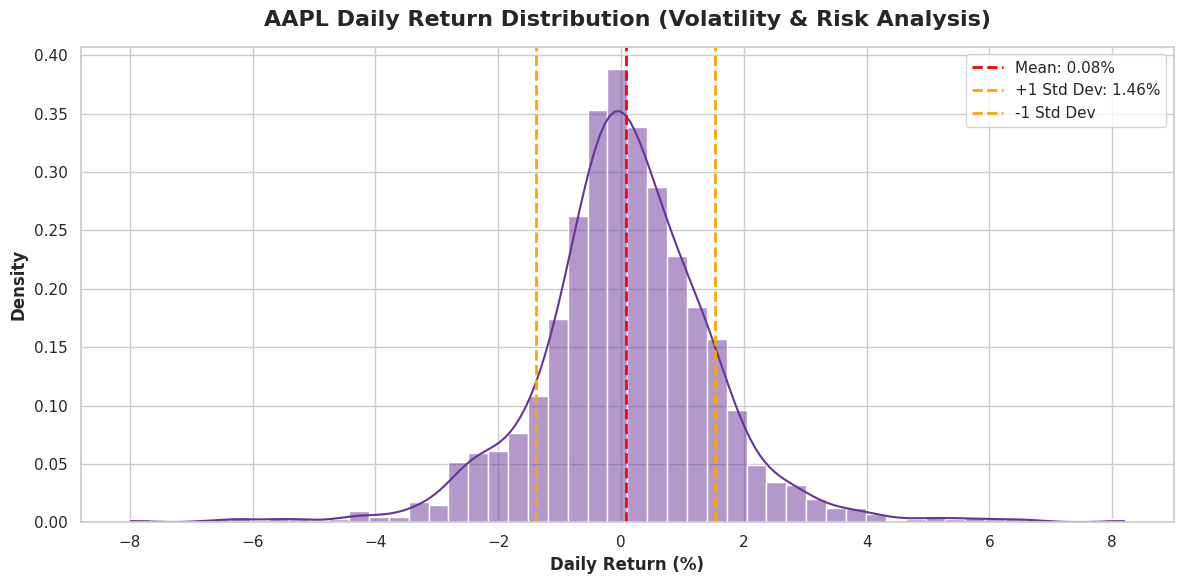

In [ ]:

sns.set_theme(style="whitegrid")

target_stock = 'AAPL'
df_risk = df[df['Name'] == target_stock].copy()
df_risk = df_risk.sort_values('date')

df_risk['Daily_Return'] = df_risk['close'].pct_change() * 100

df_risk = df_risk.dropna()

plt.figure(figsize=(12, 6))

sns.histplot(df_risk['Daily_Return'], bins=50, kde=True, color='rebeccapurple', stat='density')

plt.title(f'{target_stock} Daily Return Distribution (Volatility & Risk Analysis)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Daily Return (%)', fontsize=12, fontweight='bold')
plt.ylabel('Density', fontsize=12, fontweight='bold')

mean_return = df_risk['Daily_Return'].mean()
std_return = df_risk['Daily_Return'].std()

plt.axvline(mean_return, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_return:.2f}%')
plt.axvline(mean_return + std_return, color='orange', linestyle='dashed', linewidth=2, label=f'+1 Std Dev: {std_return:.2f}%')
plt.axvline(mean_return - std_return, color='orange', linestyle='dashed', linewidth=2, label='-1 Std Dev')

plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

In [ ]:


df.fillna(method='ffill', inplace=True)

df['sma_20'] = df['close'].rolling(window=20).mean()
df['sma_50'] = df['close'].rolling(window=50).mean()

df['daily_return'] = df['close'].pct_change()

df.dropna(inplace=True)

features_to_scale = ['open', 'high', 'low', 'close', 'volume', 'sma_20', 'sma_50', 'daily_return']

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[features_to_scale])

df_scaled = pd.DataFrame(scaled_data, columns=features_to_scale, index=df.index)

print(df_scaled.head())

/tmp/ipykernel_511/515965829.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


        open      high       low     close    volume    sma_20    sma_50  \
49  0.007036  0.006925  0.006884  0.006804  0.014925  0.007146  0.007012   
50  0.006713  0.007163  0.006801  0.007185  0.019899  0.007138  0.007028   
51  0.007168  0.007167  0.007130  0.007258  0.009890  0.007137  0.007049   
52  0.007310  0.007279  0.007224  0.007146  0.008975  0.007126  0.007069   
53  0.007227  0.007279  0.007209  0.007326  0.011763  0.007117  0.007089   

    daily_return  
49      0.046325  
50      0.050270  
51      0.048282  
52      0.047159  
53      0.048941  


In [ ]:


train_size = int(len(df_scaled) * 0.8)
train_data = df_scaled.iloc[:train_size]
test_data = df_scaled.iloc[train_size:]

def create_sequences(data, seq_length):
    x = []
    y = []
    for i in range(len(data) - seq_length):
        x.append(data.iloc[i:(i + seq_length)].values)
        y.append(data.iloc[i + seq_length]['close'])
    return np.array(x), np.array(y)

seq_length = 60
x_train, y_train = create_sequences(train_data, seq_length)
x_test, y_test = create_sequences(test_data, seq_length)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (495132, 60, 8)
x_test shape: (123739, 60, 8)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_test, y_test), callbacks=[early_stop])

predictions = model.predict(x_test)

mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
15473/15473 ━━━━━━━━━━━━━━━━━━━━ 171s 11ms/step - loss: 6.1103e-05 - val_loss: 1.9934e-06
Epoch 2/50
15473/15473 ━━━━━━━━━━━━━━━━━━━━ 167s 11ms/step - loss: 4.1981e-05 - val_loss: 2.7667e-06
Epoch 3/50
15473/15473 ━━━━━━━━━━━━━━━━━━━━ 169s 11ms/step - loss: 3.8671e-05 - val_loss: 3.5948e-06
Epoch 4/50
15473/15473 ━━━━━━━━━━━━━━━━━━━━ 172s 11ms/step - loss: 3.7388e-05 - val_loss: 4.5076e-06
3867/3867 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step
MSE: 1.9933633163056105e-06
MAE: 0.000549120866708577
R2 Score: 0.9959949704478375


In [ ]:
x_train_2d = x_train.reshape((x_train.shape[0], -1))
x_test_2d = x_test.reshape((x_test.shape[0], -1))

limit = 20000
x_train_ml = x_train_2d[-limit:]
y_train_ml = y_train[-limit:]

In [ ]:

rf_model = RandomForestRegressor(n_estimators=10, max_depth=5, n_jobs=-1, random_state=42)
rf_model.fit(x_train_ml, y_train_ml)
rf_preds = rf_model.predict(x_test_2d)

print("--- RANDOM FOREST BASELINE ---")
print(f"MSE: {mean_squared_error(y_test, rf_preds)}")
print(f"MAE: {mean_absolute_error(y_test, rf_preds)}")
print(f"R2 Score: {r2_score(y_test, rf_preds)}")

--- RANDOM FOREST BASELINE ---
MSE: 5.166658757526149e-06
MAE: 0.0014613096493798078
R2 Score: 0.9896192425933763


In [ ]:

lr_model = LinearRegression()
lr_model.fit(x_train_ml, y_train_ml)
lr_preds = lr_model.predict(x_test_2d)

print("--- LINEAR REGRESSION BASELINE ---")
print(f"MSE: {mean_squared_error(y_test, lr_preds)}")
print(f"MAE: {mean_absolute_error(y_test, lr_preds)}")
print(f"R2 Score: {r2_score(y_test, lr_preds)}")

--- LINEAR REGRESSION BASELINE ---
MSE: 1.6832688387944596e-06
MAE: 0.00046048871743769486
R2 Score: 0.9966180066681971


In [ ]:

lstm_preds = model.predict(x_test)
lr_preds = lr_model.predict(x_test_2d)
rf_preds = rf_model.predict(x_test_2d)

3867/3867 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step


In [ ]:

n_rows = len(y_test)

dummy_y = np.zeros((n_rows, 8))
dummy_lr = np.zeros((n_rows, 8))
dummy_lstm = np.zeros((n_rows, 8))
dummy_rf = np.zeros((n_rows, 8))

target_idx = 0

dummy_y[:, target_idx] = y_test.flatten()
dummy_lr[:, target_idx] = lr_preds.flatten()
dummy_lstm[:, target_idx] = lstm_preds.flatten()
dummy_rf[:, target_idx] = rf_preds.flatten()

y_test_actual = scaler.inverse_transform(dummy_y)[:, target_idx]
lr_preds_actual = scaler.inverse_transform(dummy_lr)[:, target_idx]
lstm_preds_actual = scaler.inverse_transform(dummy_lstm)[:, target_idx]
rf_preds_actual = scaler.inverse_transform(dummy_rf)[:, target_idx]

print("--- FIRST 5 PREDICTIONS IN ACTUAL CURRENCY (COMPARISON) ---")
for i in range(5):
    print(f"Actual: {y_test_actual[i]:.2f} | LR: {lr_preds_actual[i]:.2f} | LSTM: {lstm_preds_actual[i]:.2f} | RF: {rf_preds_actual[i]:.2f}")

--- FIRST 5 PREDICTIONS IN ACTUAL CURRENCY (COMPARISON) ---
Actual: 49.60 | LR: 49.65 | LSTM: 49.05 | RF: 48.45
Actual: 49.54 | LR: 49.69 | LSTM: 49.09 | RF: 48.45
Actual: 49.73 | LR: 49.43 | LSTM: 48.98 | RF: 48.45
Actual: 50.06 | LR: 49.71 | LSTM: 49.23 | RF: 48.45
Actual: 50.15 | LR: 50.30 | LSTM: 49.46 | RF: 48.45


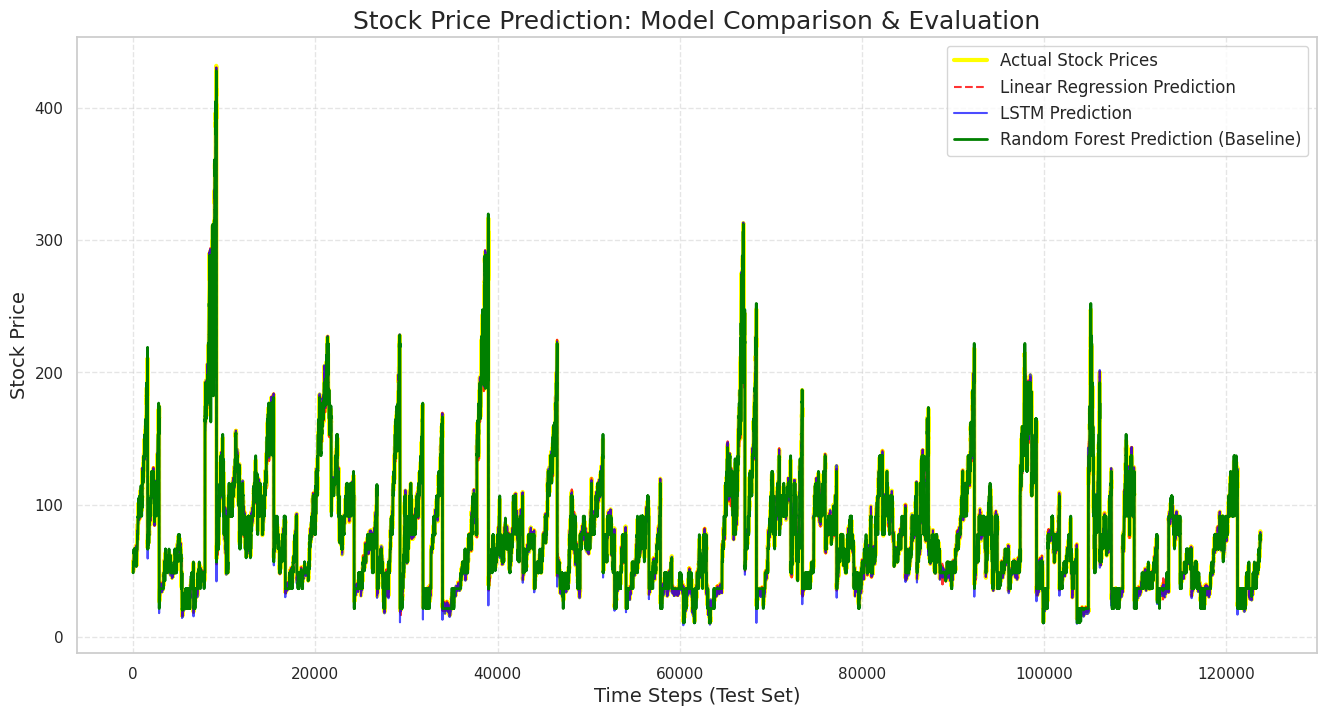

In [ ]:
# 1. Gerçek fiyatlara dönüş (Eksik kalan kısım)
y_test_actual = scaler.inverse_transform(dummy_y)[:, target_idx]
lr_preds_actual = scaler.inverse_transform(dummy_lr)[:, target_idx]
lstm_preds_actual = scaler.inverse_transform(dummy_lstm)[:, target_idx]
rf_preds_actual = scaler.inverse_transform(dummy_rf)[:, target_idx]

# 2. Grafik Çizdirme (Şov kısmı)
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))

plt.plot(y_test_actual, label='Actual Stock Prices', color='yellow', linewidth=3.0)
plt.plot(lr_preds_actual, label='Linear Regression Prediction', color='red', alpha=0.8, linestyle='--')
plt.plot(lstm_preds_actual, label='LSTM Prediction', color='blue', alpha=0.7)
plt.plot(rf_preds_actual, label='Random Forest Prediction (Baseline)', color='green', linewidth=2.0)

plt.title('Stock Price Prediction: Model Comparison & Evaluation', fontsize=18)
plt.xlabel('Time Steps (Test Set)', fontsize=14)
plt.ylabel('Stock Price', fontsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()